In [1]:
%load_ext autoreload 
#hopefully this will reload the modules when they are changed specifically when i change the plotting modules
%autoreload 2

Plot distribution of m200
Save the plot data points in txt
Check what's wrong with bootstrap

In [2]:
from myproject.redshiftGalaxyAnalysis import GalaxyAnalysis

In [3]:
galaxyAnalysisZ0 = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')


Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [4]:
import numpy as np

In [ ]:
#check the number of galaxy groups loaded
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f"Number of subhalos in GG 0: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(0).getNumSubhalos()}")
print(f"Number of subhalos in GG 10: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(10).getNumSubhalos()}")
# print(f"Number of subhalos in GG 912: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(912).getNumSubhalos()}")
rangeSat, allNumSat = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getRangeOfNumSubhalos()
print(f' Range of satellites: {rangeSat}')
print(f' numer of sat == 1: {len(np.where(np.array(allNumSat) < 5)[0])}')

In [17]:
#from galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, save in a txt file
#save all galaxy groups with id, numSat, sum of flags for all satellites, mass, central mass, central flag, central r band, first satellite mass, first satellite flag, first satellite r band
with open('tng_cluster_galaxy_groups_info.txt', 'w') as f:
    f.write('id \t,numSat \t,sumFlags \t,mass \t,centralMass \t,centralFlag \t,centralRband \t,firstSatMass \t,firstSatFlag \t,firstSatRband \n')
    for i in range(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()):
        gg = galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getGalaxyGroupI(i)
        id = gg.getGroupID()
        numSat = len(gg.getSatelliteSubhalos())
        sumFlags = np.sum([int(subhalo.getFlag()) for subhalo in gg.getSatelliteSubhalos()])
        mass = f'{gg.getMCrit200():.2e}'
        centralMass = f'{gg.getCentralSubhalo().getStellarMass():.2e}'
        centralFlag = gg.getCentralSubhalo().getFlag()
        centralRband = f'{gg.getCentralSubhalo().getDefaultRbandMagnitude():.2}'
        firstSatMass = f'{gg.getSatelliteSubhalos()[0].getStellarMass():.2e}'
        firstSatFlag = gg.getSatelliteSubhalos()[0].getFlag()
        firstSatRband = f'{gg.getSatelliteSubhalos()[0].getDefaultRbandMagnitude():.2}'
        f.write(f'{id} \t,{numSat} \t,{sumFlags} \t,{mass} \t,{centralMass} \t,{centralFlag} \t,{centralRband} \t,{firstSatMass} \t,{firstSatFlag} \t,{firstSatRband} \n')

In [ ]:
galaxyAnalysisZ0.computeAllPlots()

In [16]:
galaxyAnalysisZ0.setSnapshot(99, newsim='TNG-Cluster', luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [ ]:

galaxyAnalysisZ0.MRLDistributionPlots()

In [ ]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] == 99: #already processed these snapshots
        continue
    if snapshot[0] > 70:
        continue
    print(f"Processing snapshot {snapshot[0]}...")
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    galaxyAnalysisZ0.computeAllPlots()
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()

In [4]:
galaxyAnalysisZ0TNG300 = GalaxyAnalysis(generalRewrite=True, sim='TNG300-1',luminosityType='SDSS')

Progress: 3733/3733
Loaded 3733 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG300-1/z0p0/data/galaxy_data_TNG300-1_.hdf5
total to process: 3733
total to process: 3732alaxy Group ID 3733 / 3733
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732
total to process: 3732alaxy Group ID 3732 / 3732


In [15]:
print(galaxyAnalysisZ0.sim)

TNG300-1


Processing snapshot 99...
Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 913 with pairs : 18000496
Processing Subhalo 14/14 in Galaxy Group ID 4254241 with total pairs 91103841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG300-1
Total Galaxy Groups to process: 280 with pairs : 1753902
Processing Subhalo 7/550 in Galaxy Group ID 0 with total pairs 150975

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 54/54 in Galaxy Group ID 99 with total pairs 1431606Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_tng300z0_TNG-Cluster


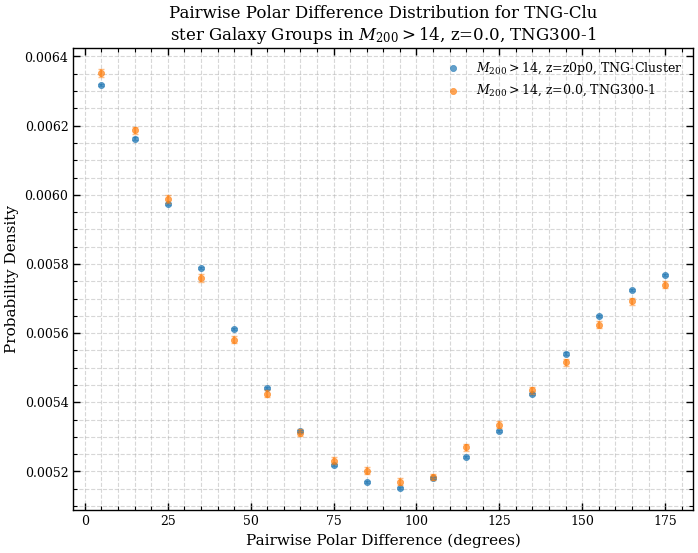

In [18]:
from myproject.utilities.snapshotEnum import SnapshotEnum
# snapshotEnum = SnapshotEnum() #(99, 0, 'z0p0')
for snapshot in SnapshotEnum.getAllSnapshots():
    if snapshot[0] < 45:
        continue #too high redshift
    if snapshot[0] != 99: #already processed these snapshots
        continue
    # if snapshot[0] > 60:
    #     continue
    print(f"Processing snapshot {snapshot[0]}...")
    listRedshiftGG = []
    galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
    groupList = []
    groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
    groupList.append((galaxyAnalysisZ0TNG300.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG300-1'))
    listRedshiftGG.append(groupList)

    polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, mrlOrPolar='polar', oneaxis=True)#, plotRows=2, plotCols=3)
    # galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
    polar_ax.legend(loc='upper right')  # Add legend to the last subplot
    polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_tng300z0_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')

In [5]:
# make a plot of the number of galaxies per unit volume, per unit r-band magnitude.  That’s the luminosity function
L=205*1e3
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
import numpy as np
import matplotlib.pyplot as plt
def plot_luminosity_function(list_gg:ListGalaxyGroup, plot_dirc:str='', label=None,
                             color=None, hist_kwargs=None, ax=None):
    rmags = []
    for gg in list_gg.getAllGalaxyGroups():
        for galaxy in gg.getSubhalos():
            rmags.append(galaxy.getRbandMagnitude()) if label=='SDSS' else rmags.append(galaxy.getDefaultRbandMagnitude())
    
    bins ='auto'
    xlow=-23
    xhigh=-7
    bins = np.linspace(xlow, xhigh, 100)
    volume =L**3
    print(f"unit volume used: {volume}")
    # print(f"rmags: {rmags}")
    
    mags = np.asarray(rmags)
    hist, edges = np.histogram(mags, bins=bins)
    width = np.diff(edges)
    values = hist.astype(float) / width
    if volume is not None:
        values = values / float(volume)
    centers = edges[:-1] + 0.5 * width
    if ax is None:
        fig, ax = plt.subplots(figsize=(8,5))
    hk = {} if hist_kwargs is None else dict(hist_kwargs)
    ax.step(centers, values, where='mid', label=label, color=color, **hk)
    ax.set_xlabel('r-band magnitude')
    ylabel = 'Number / mag / L^3'
    title = 'Luminosity Function'
    ax.set_ylabel(ylabel)
    ax.legend(loc='upper right')
    ax.set_title(title)
    ax.invert_xaxis()
    ax.set_xlim(xlow, xhigh)
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    return centers, values

unit volume used: 8615125000000000.0


(array([-22.91919192, -22.75757576, -22.5959596 , -22.43434343,
        -22.27272727, -22.11111111, -21.94949495, -21.78787879,
        -21.62626263, -21.46464646, -21.3030303 , -21.14141414,
        -20.97979798, -20.81818182, -20.65656566, -20.49494949,
        -20.33333333, -20.17171717, -20.01010101, -19.84848485,
        -19.68686869, -19.52525253, -19.36363636, -19.2020202 ,
        -19.04040404, -18.87878788, -18.71717172, -18.55555556,
        -18.39393939, -18.23232323, -18.07070707, -17.90909091,
        -17.74747475, -17.58585859, -17.42424242, -17.26262626,
        -17.1010101 , -16.93939394, -16.77777778, -16.61616162,
        -16.45454545, -16.29292929, -16.13131313, -15.96969697,
        -15.80808081, -15.64646465, -15.48484848, -15.32323232,
        -15.16161616, -15.        , -14.83838384, -14.67676768,
        -14.51515152, -14.35353535, -14.19191919, -14.03030303,
        -13.86868687, -13.70707071, -13.54545455, -13.38383838,
        -13.22222222, -13.06060606, -12.

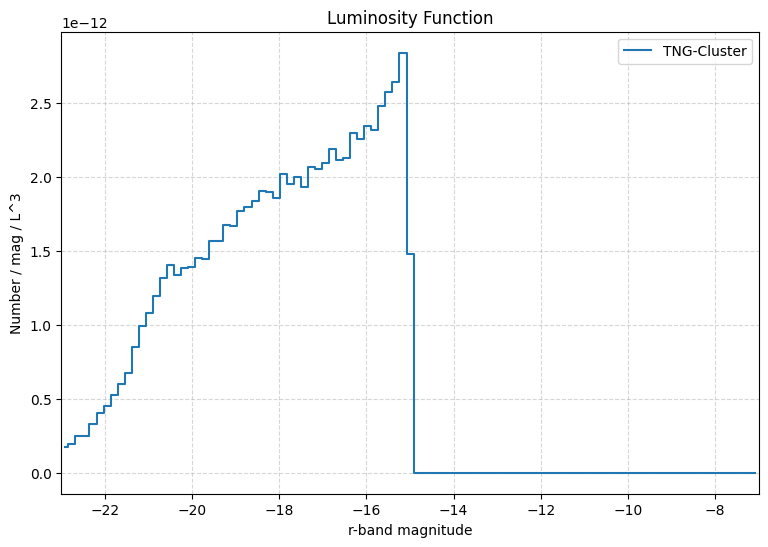

In [7]:
figSDSS, axSDSS = plt.subplots(figsize=(9,6))
plot_luminosity_function(galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, ax=axSDSS, label='TNG-Cluster')


In [9]:
%pwd

'/home/poulin.al/git/sat-lopsidedness/src/myproject'

In [10]:
#given a txt file that looks like:
# '''
# # # TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)
# # Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.
# # If you use quantities from this table, please also cite the relevant paper, when indicated for a column.
# # [352] halos, all properties at [z=0] unless specified otherwise.
# #
# # columns: 
# # [1] origID: Original Parent Halo ID (for reference only)
# # [2] haloID: TNG-Cluster Halo ID (in the group catalog)
# # [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]
# # [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]
# # [5] r200c: Halo radius r200c [Mpc]
# #
#    0        0 15.29 15.13 2.629 1.711 12.58 12.76 11.74 10.51 0.145   nan 45.28 -3.69  34.05 -0.79  8.11 0.49 854 502 248  62  CC  0.45  39.57  -0.93  1.69 0.14 0.64 0  0.23  0.67  0.55  0.60  0.45  0.72 
#    1   252455 15.40 15.27 2.871 1.912 12.16 12.49 11.37  9.35 0.126   nan 44.96 -3.48  11.91 -2.16  8.36 0.38 708 423 202  63 NCC 12.96 566.18  -2.20  0.19 0.01 0.12 0  1.91  2.81  1.84  1.35  1.75  1.93 
#    2   476245 15.16 14.99 2.378 1.541 12.16 12.40 11.82 10.17 0.132   nan 44.59 -3.94   3.61 -2.35  8.17 0.39 718 427 210  68 NCC 16.48 515.67  -2.41  0.19 0.01 0.10 0  1.41  2.29  2.23  1.04  1.26  1.63 
#    3   692426 15.36 15.14 2.782 1.731 12.53 12.72 11.55 10.19 0.149   nan 45.06 -3.61   9.16 -1.33  7.95 0.08 628 363 167  49 WCC  1.13  57.04  -1.44  0.81 0.07 0.26 0  1.02  0.46  0.93  2.68  2.72  2.84 
# '''
   
#read the id's
primary_halo_ids = []
with open('tng-cluster-primaryinfo.txt', 'r') as file:
    lines = file.readlines()
    for line in lines:
        print(line)
        if line.startswith('#') or line.strip() == '':
            continue  # Skip header or empty lines
        parts = line.split()
        if len(parts) > 1:
            primary_halo_ids.append(int(parts[1]))  # Assuming haloID is the second column
        

# TNG-Cluster Catalog (see: https://www.tng-project.org/data/cluster/ and http://arxiv.org/abs/2311.06338)

# Note: this table is dynamic, and new columns are frequently added. Requests for additions are welcome.

# If you use quantities from this table, please also cite the relevant paper, when indicated for a column.

# [352] halos, all properties at [z=0] unless specified otherwise.

#

# columns: 

# [1] origID: Original Parent Halo ID (for reference only)

# [2] haloID: TNG-Cluster Halo ID (in the group catalog)

# [3] mhalo_200c: Halo mass within r200c [log M$_\odot$]

# [4] mhalo_500c: Halo mass within r500c [log M$_\odot$]

# [5] r200c: Halo radius r200c [Mpc]

# [6] r500c: Halo radius r500c [Mpc]

# [7] mstar_30kpc: Stellar mass within 30 kpc [log(M$_\star$ / M$_\odot$]

# [8] mstar_100kpc: Stellar mass within 100 kpc [log(M$_\star$ / M$_\odot$]

# [9] mhi_halo: Neutral HI mass within the (FoF) halo [log M$_\odot$]

# [10] mass_smbh: Mass of central SMBH [log M$_\odot$]

# [11

In [24]:
galaxyAnalysisZ0PrimaryOnly = GalaxyAnalysis(generalRewrite=True, sim='TNG-Cluster',luminosityType='Default')

Progress: 5612/5612
Loaded 5612 galaxy groups from HDF5.
Loaded galaxy data from /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/data/galaxy_data_TNG-Cluster_.hdf5
total to process: 5612
total to process: 5052alaxy Group ID 5612 / 5612
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052
total to process: 5052alaxy Group ID 5052 / 5052


In [25]:
from myproject.utilities.ListGalaxyGroup import ListGalaxyGroup
#now filter to only the primary halo ids that are in our galaxy groups
filtered_primary_gt14_list_of_galaxy_groups = []
for gg in galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getAllGalaxyGroups():
    if gg.getGroupID() in primary_halo_ids:
        print(f"Galaxy group with primary halo ID {gg.getGroupID()} is in the TNG-Cluster catalog.")
        filtered_primary_gt14_list_of_galaxy_groups.append(gg)
        
galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups = ListGalaxyGroup(filtered_primary_gt14_list_of_galaxy_groups, headerInformation=galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getHeaderInformation())        

Galaxy group with primary halo ID 0 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4356618 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4461296 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4561713 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4656216 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4753637 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 476245 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4854863 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 4959833 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5059214 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5160063 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5251697 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5348819 is in the TNG-Cluster catalog.
Galaxy group with primary halo ID 5432141 is in the TNG-Cl

In [28]:
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')
print(f'Number of galaxy groups loaded: {galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups.getNumGalaxyGroups()}')


Number of galaxy groups loaded: 352
Number of galaxy groups loaded: 352


COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=z0p0, TNG-Cluster
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841COMPUTING FOR redshift index: 0, label: $M_{200}>14$, z=0.0, TNG-Cluster only primaries
Total Galaxy Groups to process: 352 with pairs : 17732249
Processing Subhalo 6/626 in Galaxy Group ID 0 with total pairs 195625

/home/poulin.al/git/sat-lopsidedness/src/myproject/utilities/plottingTools.py:236: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  sc = ax.scatter(x, y, c=scatter_color, cmap=cmap, alpha=alpha, s=s,


Processing Subhalo 639/639 in Galaxy Group ID 4254230 with total pairs 203841Figure saved to: /scratch/poulin.al/lopsided/TNG-Cluster/z0p0/plots/pairwise_polar_difference_cluster_vs_cluster-primaries_TNG-Cluster


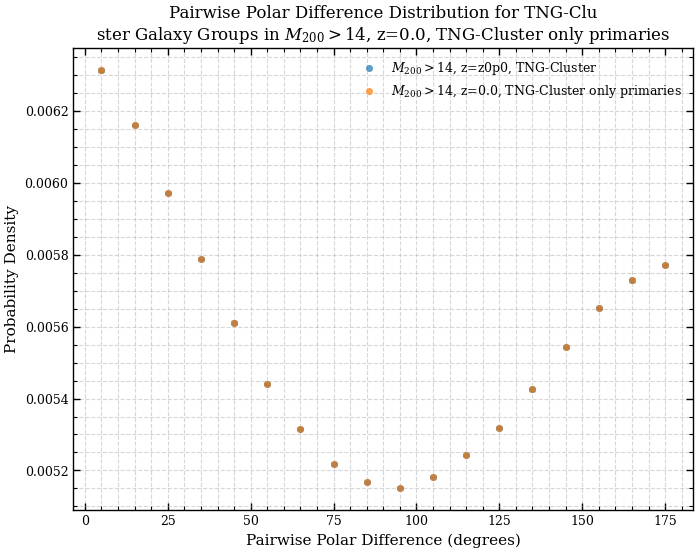

In [27]:
listRedshiftGG = []
# galaxyAnalysisZ0.setSnapshot(snapshot[0], newsim='TNG-Cluster', luminosityType='Default')
snapshot=(99,)
groupList = []
groupList.append((galaxyAnalysisZ0.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z={galaxyAnalysisZ0.snapshot_dic[snapshot[0]][1]}, TNG-Cluster'))
groupList.append((galaxyAnalysisZ0PrimaryOnly.filtered_gt14_list_of_galaxy_groups, f'$M_{{200}}>14$, z=0.0, TNG-Cluster only primaries'))
listRedshiftGG.append(groupList)

polar_plotter, polar_fig, polar_ax = galaxyAnalysisZ0.overlay_polar_pairwise_across_redshifts(listRedshiftGG=listRedshiftGG, typePlot='polar', oneaxis=True)#, plotRows=2, plotCols=3)
# galaxyAnalysisZ0.plot_M200_distribution_for_all_mass_bins()
polar_ax.legend(loc='upper right')  # Add legend to the last subplot
polar_plotter.save_figure(polar_fig, galaxyAnalysisZ0.scratchPlotDirc + f'/pairwise_polar_difference_cluster_vs_cluster-primaries_{galaxyAnalysisZ0.sim}{galaxyAnalysisZ0.plotEndingFormat}')